<a href="https://colab.research.google.com/github/isumakm/Weather-Prediction-and-Crop-Recommendation-System-/blob/Single-Crop-Analysis/MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)

import joblib

1) Load dataset

In [ ]:
DATA_PATH = "Crop_training_data_FULL.csv"   # change if needed
df = pd.read_csv(DATA_PATH)

 2) TARGET + FEATURES

In [ ]:
# Your label column name (from your generator):
TARGET_COL = "suitability_class"  # "Suitable" / "Unsuitable"

# Convert to binary (1=Suitable, 0=Unsuitable)
df[TARGET_COL] = df[TARGET_COL].map({"Unsuitable": 0, "Suitable": 1})

# Drop rows if any missing target
df = df.dropna(subset=[TARGET_COL])

# Features: remove target and optional helper cols
DROP_COLS = [TARGET_COL]

# If you have "suitability" numeric score in dataset, drop it (to avoid leakage)
if "suitability" in df.columns:
    DROP_COLS.append("suitability")

X = df.drop(columns=DROP_COLS)
y = df[TARGET_COL]



3) AUTO DETECT NUMERIC + CATEGORICAL FEATURES

In [ ]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['temperature', 'rainfall', 'sunshine_hours', 'ph', 'organic_carbon', 'cec', 'awc', 'bulk_density', 'rooting_depth_m', 'texture_code']
Categorical features: ['crop', 'texture']


4) PREPROCESSOR

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)



5) TRAIN / TEST SPLIT

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



6) BUILD MLP MODEL

In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # can tune later
    activation="relu",
    solver="adam",
    alpha=1e-4,                   # L2 regularization
    learning_rate_init=1e-3,
    max_iter=500,
    early_stopping=True,
    random_state=42
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", mlp)
])

 7) TRAIN

In [ ]:
model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['temperature', 'rainfall',
                                                   'sunshine_hours', 'ph',
                                                   'organic_carbon', 'cec',
                                                   'awc', 'bulk_density',
                                                   'rooting_depth_m',
                                                   'texture_code']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['crop', 'texture'])])),
                ('classifier',
                 MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32),
                               max_iter=500, random_state=42))])

8) EVALUATE

In [ ]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
auprc = average_precision_score(y_test, y_proba)

print("\n=== MLP RESULTS ===")
print(f"Accuracy : {acc:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")
print(f"AUPRC     : {auprc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


=== MLP RESULTS ===
Accuracy : 0.7714
ROC AUC   : 0.8345
AUPRC     : 0.7680

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.84      0.81       249
           1       0.74      0.67      0.71       171

    accuracy                           0.77       420
   macro avg       0.77      0.76      0.76       420
weighted avg       0.77      0.77      0.77       420



9) PLOTS: ROC + PR CURVE

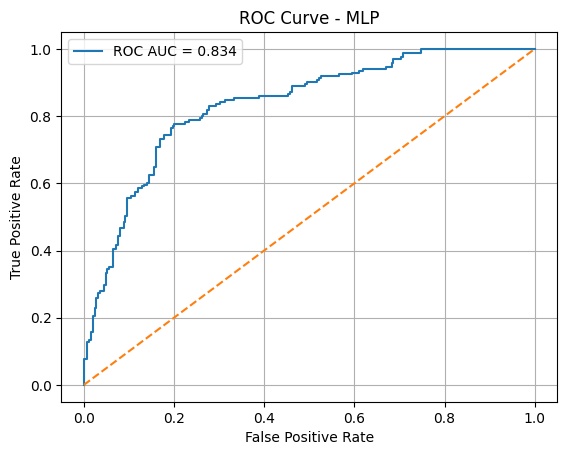

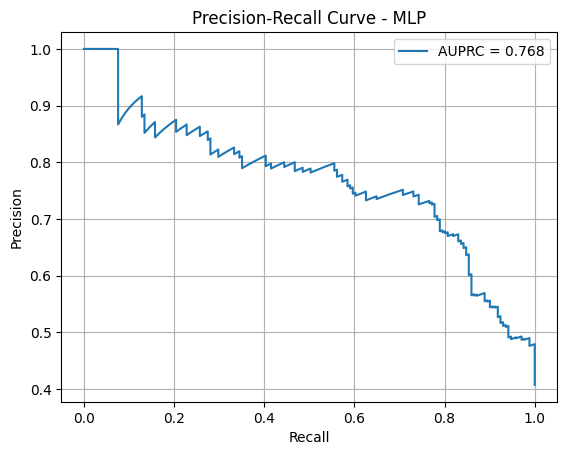

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MLP")
plt.legend()
plt.grid(True)
plt.show()

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.figure()
plt.plot(recall, precision, label=f"AUPRC = {auprc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - MLP")
plt.legend()
plt.grid(True)
plt.show()

10) SAVE PIPELINE

In [ ]:
joblib.dump(model, "mlp_crop_suitability_pipeline.pkl")
print("\nSaved model as: mlp_crop_suitability_pipeline.pkl")


Saved model as: mlp_crop_suitability_pipeline.pkl


Hyperparameter tuning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)

from scipy.stats import loguniform
import joblib

In [ ]:
DATA_PATH = "Crop_training_data_FULL.csv"
df = pd.read_csv(DATA_PATH)

TARGET_COL = "suitability_class"
df[TARGET_COL] = df[TARGET_COL].map({"Unsuitable": 0, "Suitable": 1})
df = df.dropna(subset=[TARGET_COL])

# Avoid leakage if you included "suitability" score
drop_cols = [TARGET_COL]
if "suitability" in df.columns:
    drop_cols.append("suitability")

X = df.drop(columns=drop_cols)
y = df[TARGET_COL]


In [ ]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['temperature', 'rainfall', 'sunshine_hours', 'ph', 'organic_carbon', 'cec', 'awc', 'bulk_density', 'rooting_depth_m', 'texture_code']
Categorical features: ['crop', 'texture']


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", MLPClassifier(
        max_iter=800,
        early_stopping=True,
        random_state=42
    ))
])

In [ ]:
param_dist = {
    "classifier__hidden_layer_sizes": [(64,), (128,), (64, 32), (128, 64), (128, 64, 32)],
    "classifier__activation": ["relu", "tanh"],
    "classifier__solver": ["adam"],  # keep stable
    "classifier__alpha": loguniform(1e-6, 1e-2),  # regularization
    "classifier__learning_rate_init": loguniform(1e-4, 1e-2),
    "classifier__batch_size": [32, 64, 128]
}

In [ ]:
search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=25,               # increase to 50 if you want better search
    scoring="average_precision",  # AUPRC focus
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
print("\n=== BEST PARAMETERS ===")
print(search.best_params_)
print(f"Best CV AUPRC: {search.best_score_:.4f}")


Fitting 3 folds for each of 25 candidates, totalling 75 fits

=== BEST PARAMETERS ===
{'classifier__activation': 'relu', 'classifier__alpha': np.float64(0.0015352246941973493), 'classifier__batch_size': 128, 'classifier__hidden_layer_sizes': (64, 32), 'classifier__learning_rate_init': np.float64(0.0036256176345762273), 'classifier__solver': 'adam'}
Best CV AUPRC: 0.8539


In [ ]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
auprc = average_precision_score(y_test, y_proba)

print("\n=== TEST RESULTS (BEST MLP) ===")
print(f"Accuracy : {acc:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")
print(f"AUPRC    : {auprc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


=== TEST RESULTS (BEST MLP) ===
Accuracy : 0.8071
ROC AUC  : 0.8908
AUPRC    : 0.8609

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       249
           1       0.77      0.74      0.76       171

    accuracy                           0.81       420
   macro avg       0.80      0.80      0.80       420
weighted avg       0.81      0.81      0.81       420



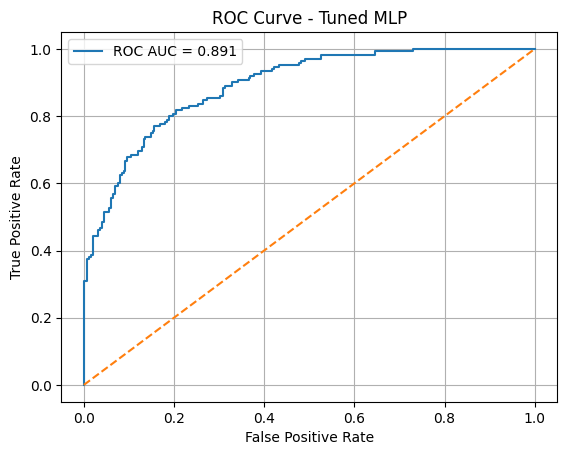

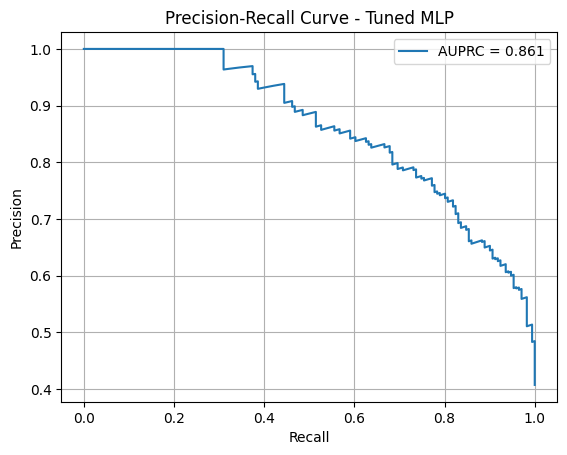

In [ ]:
# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned MLP")
plt.legend()
plt.grid(True)
plt.show()

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.figure()
plt.plot(recall, precision, label=f"AUPRC = {auprc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Tuned MLP")
plt.legend()
plt.grid(True)
plt.show()

